In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [39]:
# read dataset
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/TelecomCustomerChurn.csv')
df

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


In [40]:
df.shape

(7043, 21)

In [41]:
df.isnull().sum()

customerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

the data does not contains any null values 

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   Gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Analysis

In [43]:
## removing customer_id column as it is not important
df.drop(["customerID"], inplace = True, axis = 1)

In [44]:
df.TotalCharges.dtype

<StringDtype(storage='python', na_value=nan)>

In [45]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [46]:
## Tenure 

df["Tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure, dtype: float64

In [47]:
df["Tenure"].value_counts().head(10)

Tenure
1     613
72    362
2     238
3     200
4     176
71    170
5     133
7     131
8     123
70    119
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

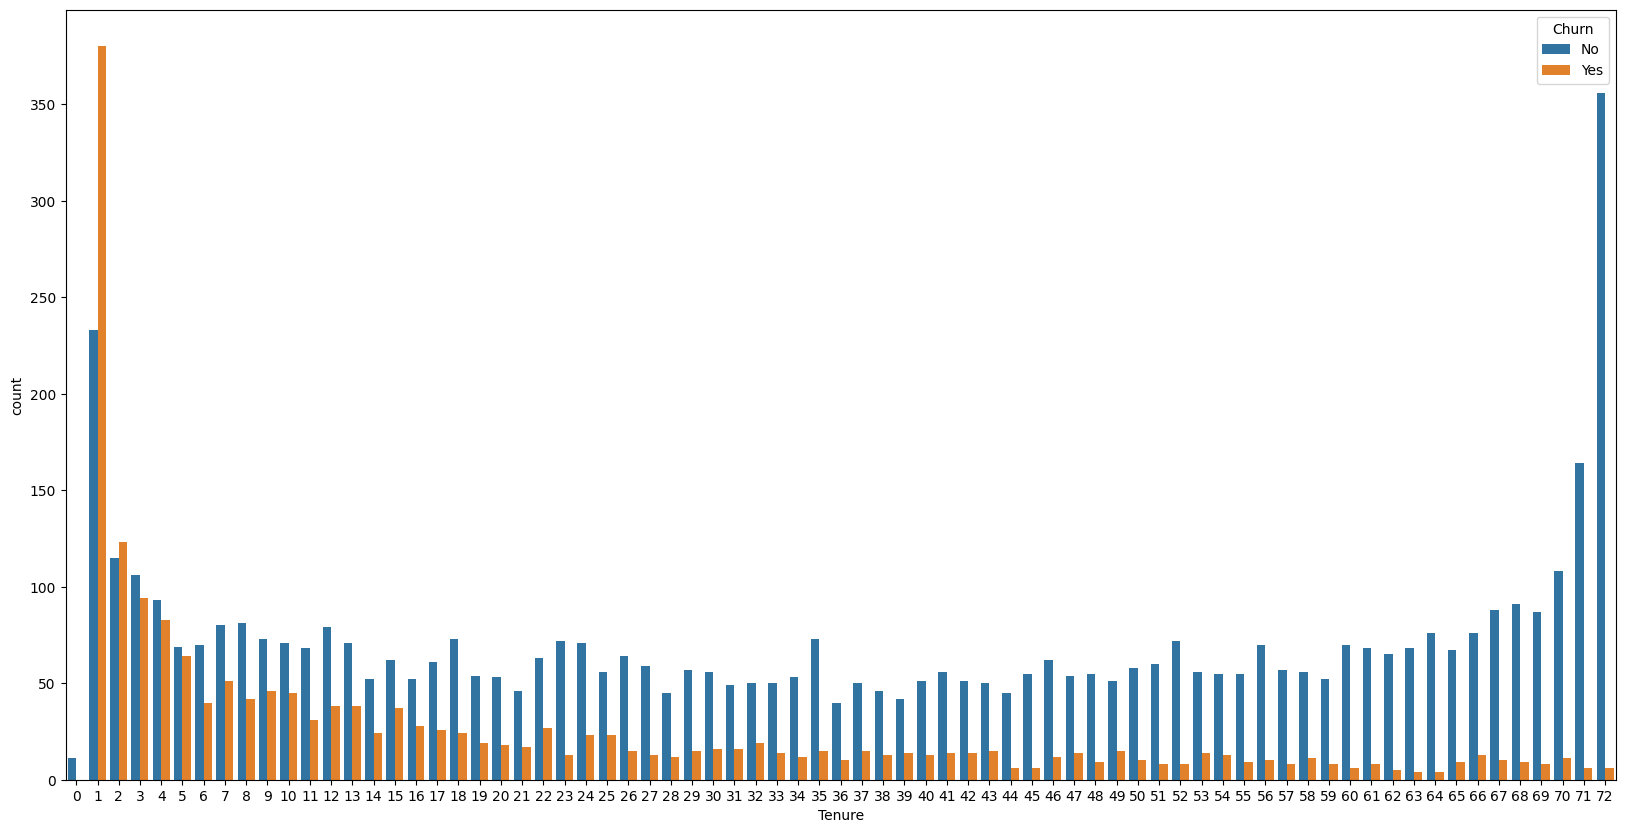

In [48]:
plt.figure(figsize=(20,10))
sns.countplot(x = 'Tenure' ,hue = 'Churn', data = df)
plt.show

Insights :
-The graph clearly shhows that, customers having high tenure has a lower churn rate.
-customers within the first five months has higher probablity of leaving/churn rate (we will analyse this in detail later wrt other columns)

In [49]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

insight : the churn rate is arount 27% 

In [50]:
for col in ['Gender','SeniorCitizen','Partner','Dependents','Contract','PaymentMethod']:
    print(df[col].value_counts(normalize=True))

Gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64
SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64
Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64
Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64
Contract
Monthly     0.550192
Two year    0.240664
One year    0.209144
Name: proportion, dtype: float64
PaymentMethod
Manual                       0.564674
Bank transfer (automatic)    0.219225
Credit card (automatic)      0.216101
Name: proportion, dtype: float64


In [51]:
df[['Tenure','MonthlyCharges']].describe()

,Tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


### Insights : 
##### The percentage of customers based on gender are almost same 
##### Around 84 percent of the customers are the senior citizens ( good news senior cetizens tends to have lower churn rate)
#####  The percentage of of customers based on partners too are almost same, (no partner customers tends to have higher churn rate due to more flexibility)
##### Around 70 percent of the customers are non dependent 
##### more than 55 percent of the customers pays on monthly basis (high number)
##### more than 56 percent of the customer perfer paying manually (high number)

In [52]:
def stacked_plot(df, group, target):
    fig, ax = plt.subplots(figsize=(6, 4))
    
    temp_df = (
        df.groupby([group, target])
        .size()
        .unstack(fill_value=0)
    )
    
    temp_df = temp_df.div(temp_df.sum(axis=1), axis=0)
    
    temp_df.plot(kind='bar', stacked=True, ax=ax, color=["mediumturquoise", "cyan"])
    
    ax.set_xlabel(group)
    ax.set_ylabel('Churn Percentage')
    ax.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()

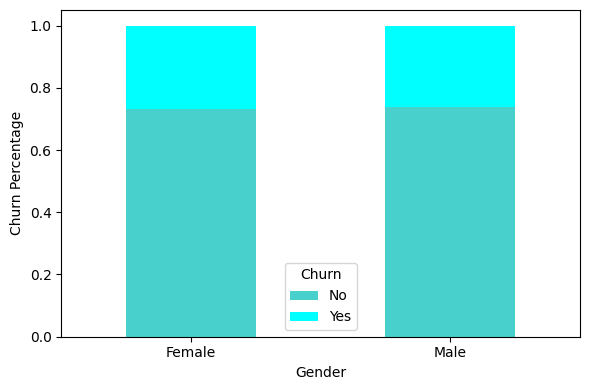

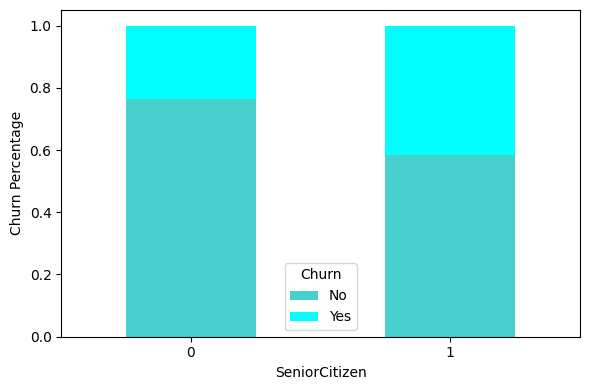

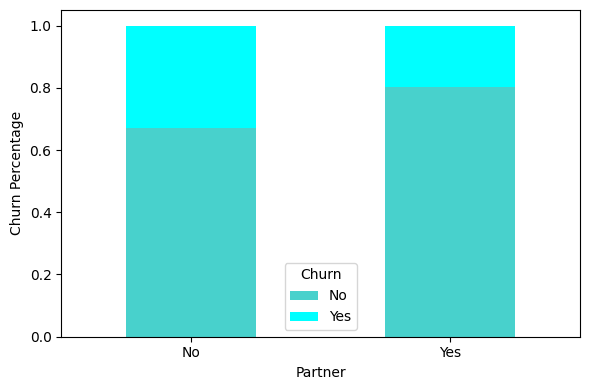

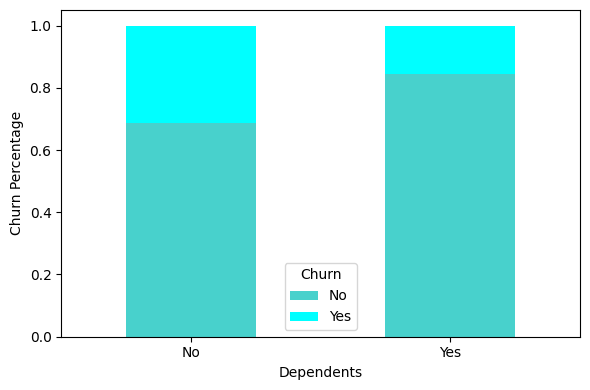

In [53]:
stacked_plot(df, "Gender", "Churn")
stacked_plot(df, "SeniorCitizen", "Churn")
stacked_plot(df, "Partner", "Churn")
stacked_plot(df, "Dependents", "Churn")

#### Insights 
1.gender biased churn prediction is not seen (which is not strange)
2.senior citizens shows less percentage of churn rate (which does makes sence)
3.having no partner or dependents shows more than 30% of churn rate (less commited group) 

In [54]:
df[['Tenure','MonthlyCharges','TotalCharges']].describe()

,Tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


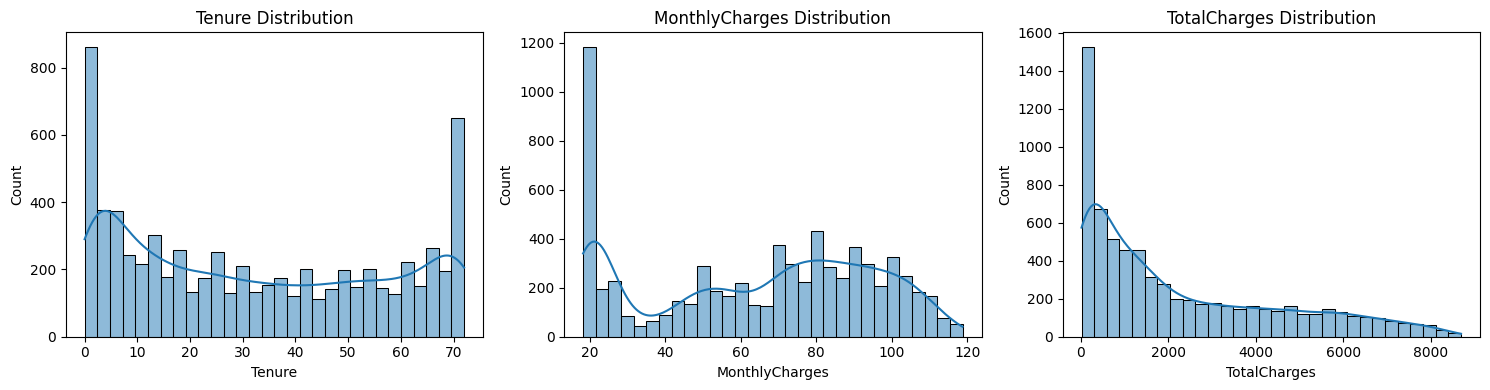

In [55]:
plt.figure(figsize=(15, 4))
num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

#### Insights 
 The KDE plots indicate that Tenure and MonthlyCharges are not normally distributed and exhibit mild skewness. Since most machine learning algorithms do not assume normality, (thus transformation is not mandatory). However, for models sensitive to feature distribution or scale (e.g., linear models), applying transformations or scaling may improve performance. we will validate this empirically during model training.

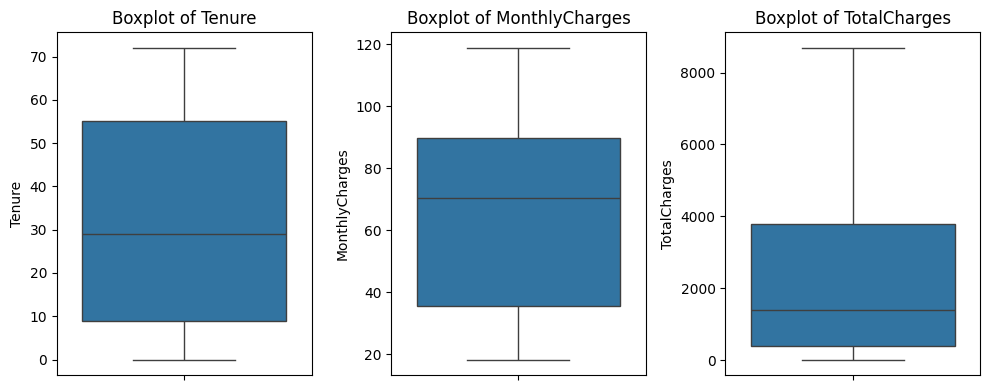

In [56]:
plt.figure(figsize=(10, 4))
num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

#### Insights 
- No major outliers in Tenure & MonthlyCharges 
- Strong skewness in TotalCharges (these are not outliers they are high value customers )
- Here, skewness seems logical, its not problematic

<Axes: xlabel='Tenure', ylabel='TotalCharges'>

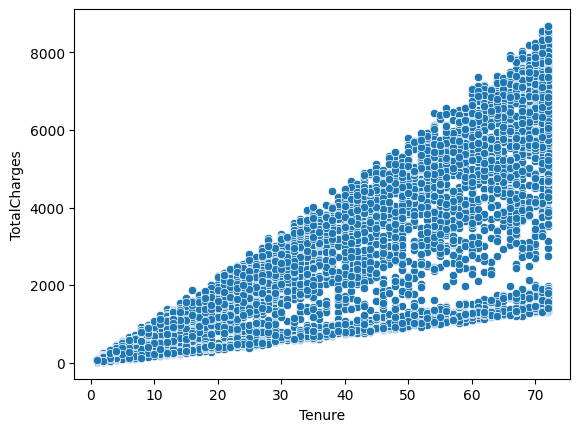

In [57]:
sns.scatterplot(x='Tenure', y='TotalCharges', data=df)

#### Insight
The relationship is linear, and is strong, which proves our above point.

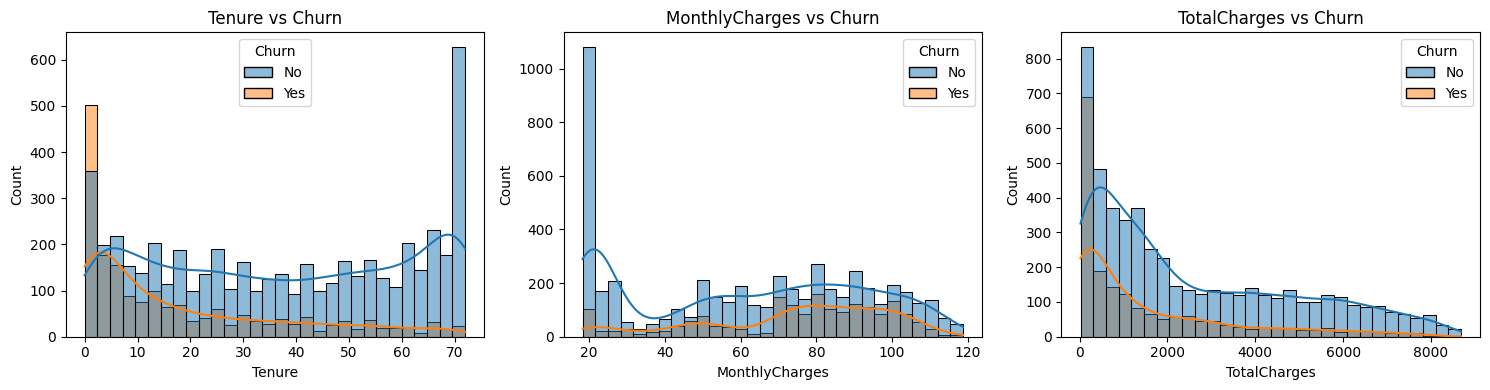

In [58]:
plt.figure(figsize=(15, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30)
    plt.title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

In [37]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Monthly,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


#### Insights 
- Tenure → low tenure seems to have high churn (which is understandable)
- MonthlyCharges → higher churn is mostly seen by the customers who have higher monthly charges 
- TotalCharges → this is tricky to say needs more analysis. (depends on tenure)

In [59]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Manual,0.653256,0.346744


In [60]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [61]:
pd.crosstab(df['Partner'], df['Churn'], normalize='index')

Churn,No,Yes
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


In [62]:
pd.crosstab(df['Dependents'], df['Churn'], normalize='index')

Churn,No,Yes
Dependents,,
No,0.687209,0.312791
Yes,0.845498,0.154502


#### Insights
- manual payment mode has the highest churn rate 
- fibre optics shows a very high churn rate 

##### Phone Services and Multiple lines 

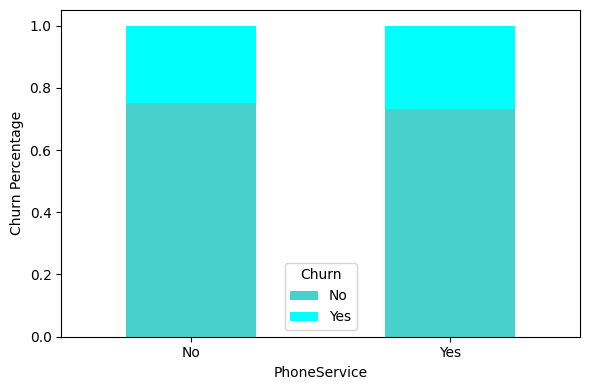

In [64]:
stacked_plot(df, 'PhoneService', "Churn")

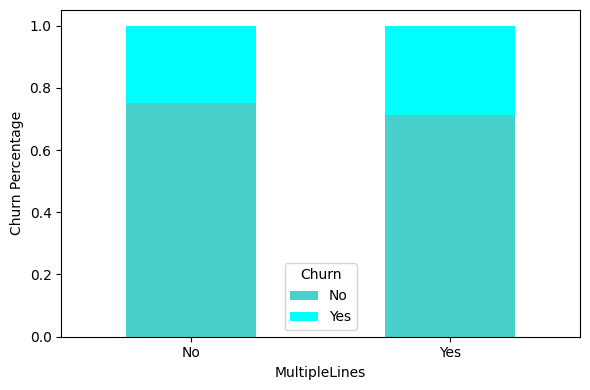

In [65]:
stacked_plot(df, 'MultipleLines', "Churn")

#### Insights 
both phone services and multiple lines don't really affect churn rate

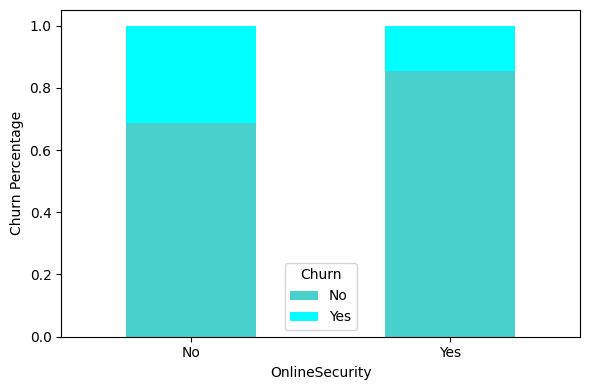

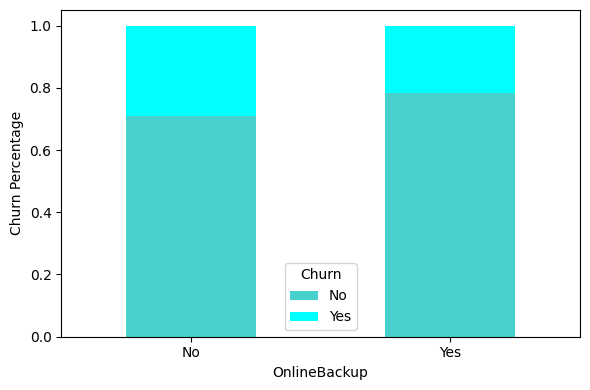

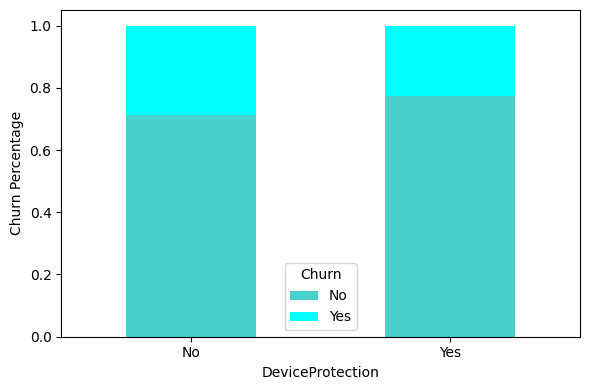

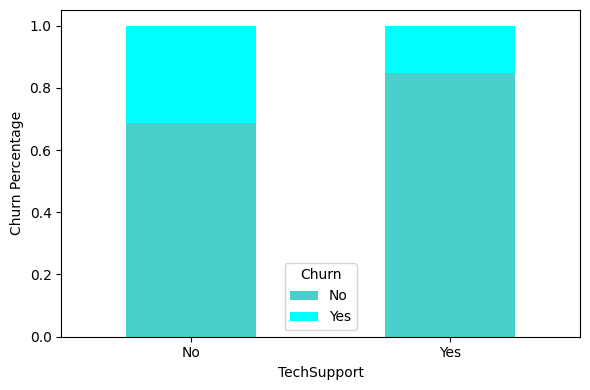

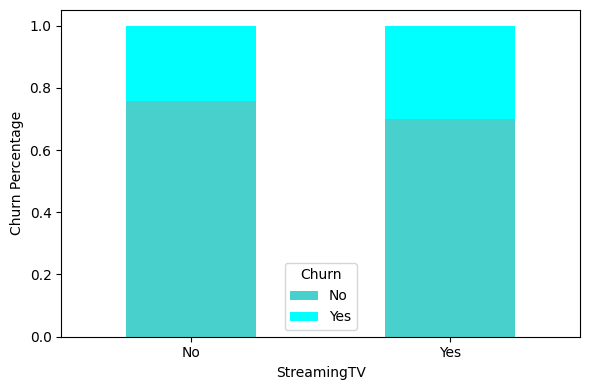

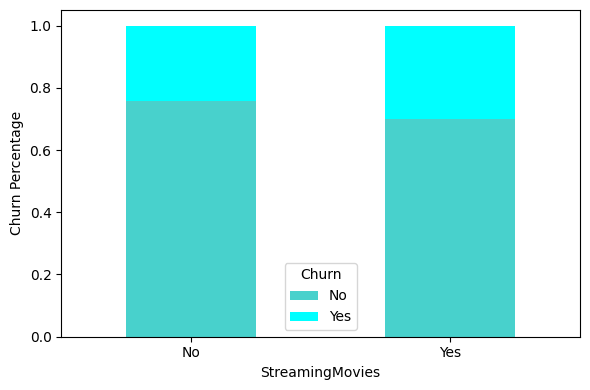

In [66]:
stacked_plot(df, "OnlineSecurity", "Churn")
stacked_plot(df, "OnlineBackup", "Churn")
stacked_plot(df, "DeviceProtection", "Churn")
stacked_plot(df, "TechSupport", "Churn")
stacked_plot(df, "StreamingTV", "Churn")
stacked_plot(df, "StreamingMovies", "Churn")

#### Insights 
- OnlineSecurity, OnlineBackup, TechSupport (strongest) -> customers who subscribe to these services churn significantly less
- Streaming movies , Streaming TV -> these are entertainment add-ons Don’t influence long-term commitment Easy to drop, easy to switch providers
- Device Protection -> shows very slich reduction in the churn rate.

#### Churn is primarily driven by functional value (security, support, reliability) rather than entertainment features. Customers stay when the service is essential, not when it is just enjoyable.

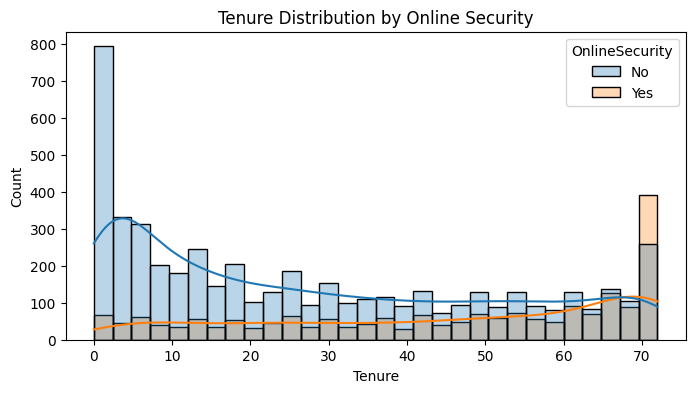

In [80]:
plt.figure(figsize=(8,4))

sns.histplot(data=df, x='Tenure', hue='OnlineSecurity',
             kde=True, bins=30, alpha=0.3)

plt.title("Tenure Distribution by Online Security")
plt.show()

Insight : customers having lower tenure are very unlikely to have online security as a service

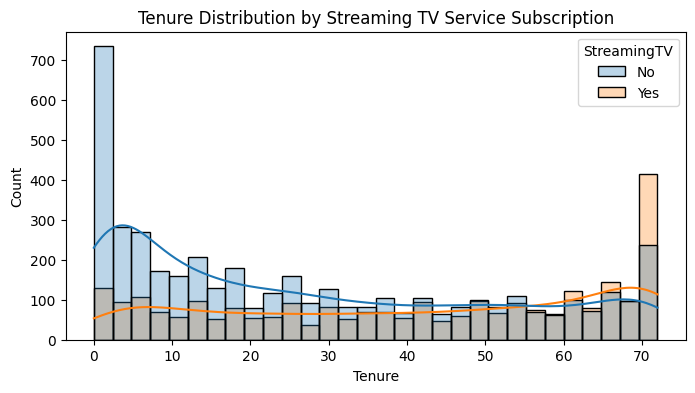

In [82]:
plt.figure(figsize=(8,4))

sns.histplot(data=df, x='Tenure', hue='StreamingTV',
             kde=True, bins=30, alpha=0.3)

plt.title("Tenure Distribution by Streaming TV Service Subscription")
plt.show()


Insight : customers wtih higher tenure are more likely to adapt to streaming TV services 

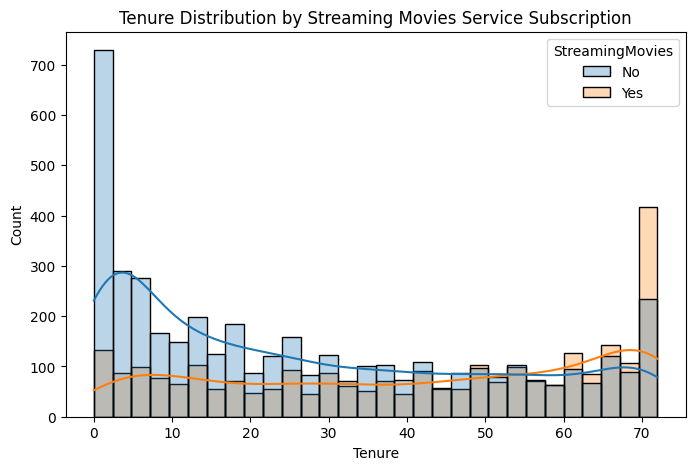

In [83]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Tenure', hue='StreamingMovies',
             kde=True, bins=30, alpha=0.3)

plt.title("Tenure Distribution by Streaming Movies Service Subscription")
plt.show()

Insight : customers wtih higher tenure are more likely to adapt to streaming movies services 

In [88]:
## Internet service analysis

df.InternetService.value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

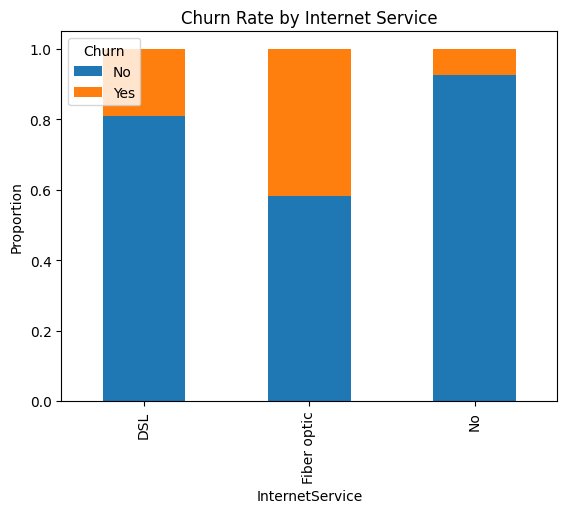

In [101]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index').plot(kind='bar', stacked=True)

plt.title("Churn Rate by Internet Service")
plt.ylabel("Proportion")
plt.show()

#### Insights 
- With no internet as a service the churn rate is the lowest 
- fibre optics has comparitively higher churn rate than DSL , even though optic fibre dilevers faster internet speed than DSL, the reason could probably be the cost.

<Axes: xlabel='InternetService', ylabel='count'>

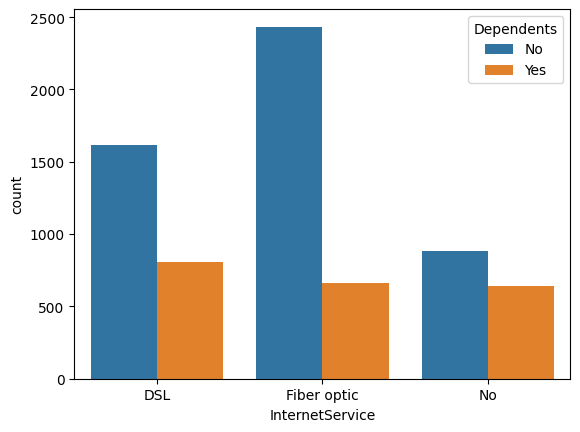

In [105]:
sns.countplot(data=df, x='InternetService', hue='Dependents')

#### Insights 
- Majority of customers do not have dependents
- Customers without dependents prefer Fiber optic services
- Customers with dependents show relatively higher preference for DSL
- “No Internet Service” category is less influenced by dependents

In [107]:
df.PaymentMethod.value_counts()

PaymentMethod
Manual                       3977
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

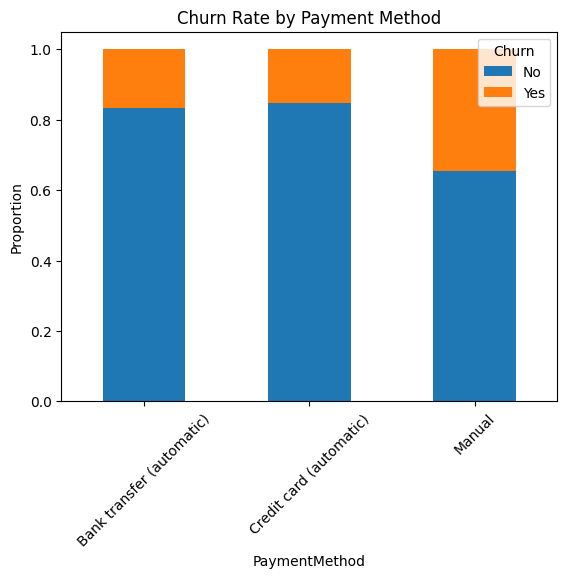

In [106]:
## payment method

pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index').plot(kind='bar', stacked=True)

plt.title("Churn Rate by Payment Method")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.show()

#### Insights 
payment mode as manual shows highest churn 

In [108]:
## paperless biling 

df.PaperlessBilling.value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

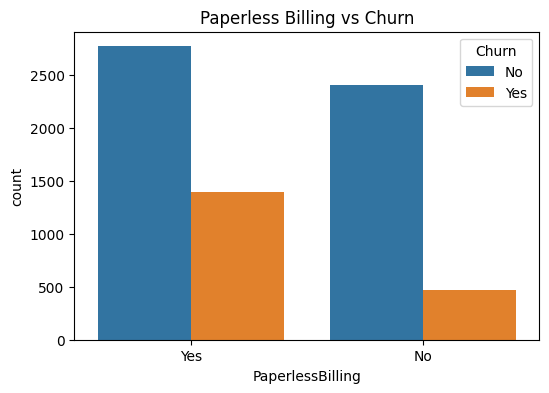

In [110]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
plt.title("Paperless Billing vs Churn")

plt.show()

In [111]:
### contract
df.Contract.value_counts()

Contract
Monthly     3875
Two year    1695
One year    1473
Name: count, dtype: int64

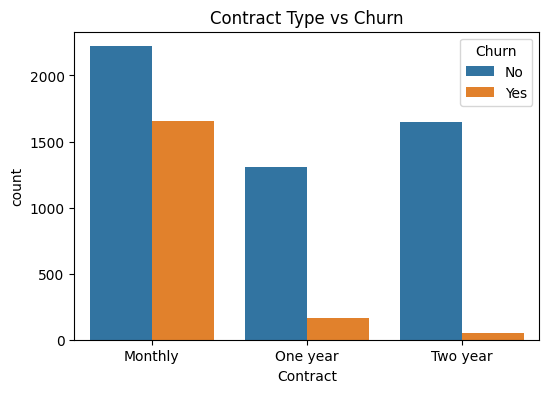

In [112]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Contract Type vs Churn")

plt.show()

#### Insights 
customers that pays on the monthly basis has the hisghest churn rate (more volatile customers)

In [119]:
### total charges 

df.TotalCharges.describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   Tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [124]:
df.TotalCharges.isna().sum()
## there are some 11 missing values in the column TotalCharges

np.int64(11)

In [126]:
df[df.TotalCharges.isna()]

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No,No,No,No,No,No,Two year,No,Manual,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Manual,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No,No,No,No,No,No,Two year,No,Manual,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No,No,No,No,No,No,Two year,No,Manual,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No,No,No,No,No,No,Two year,No,Manual,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No,No,No,No,No,No,Two year,No,Manual,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No,No,No,No,No,No,One year,Yes,Manual,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Manual,73.35,NaN,No


the data shows there tenure is 0, also these customers have paid monthly charges but their total charges is 0 that means these are the customers that have joined very recently, thus we will encode there total charges column by 0 instead of NaN values.

In [127]:
df.loc[df["TotalCharges"].isnull(), 'TotalCharges'] = 0
df.isnull().any().any()

np.False_

In [128]:
df['TotalCharges'] = df["TotalCharges"].astype(float)

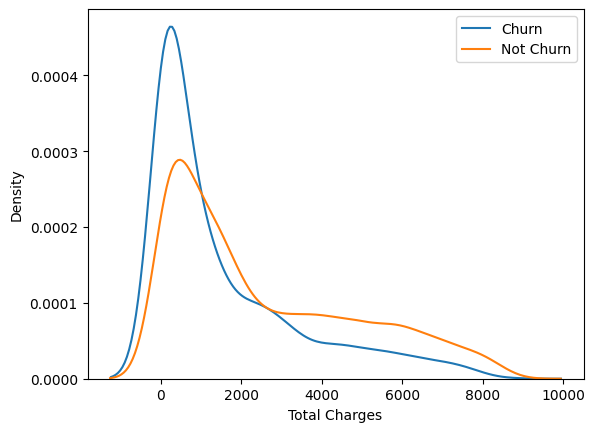

In [135]:
Churn = df[df.Churn=="Yes"]
Not_Churn = df[df.Churn=="No"]
ig, ax = plt.subplots()
sns.kdeplot(Churn["TotalCharges"],label = "Churn", ax= ax)
sns.kdeplot(Not_Churn["TotalCharges"], label = "Not Churn", ax=ax)
ax.set_xlabel("Total Charges")
plt.legend()
plt.show()

#### Insight :
The density of total charges for churning customers are high around 0. As many customers cancel the subsription in 1-2 months.

In [132]:
## Monthly charges 

df.MonthlyCharges.describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

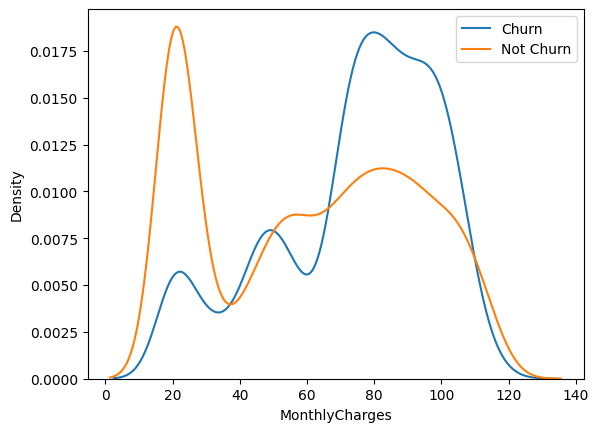

In [134]:
sns.kdeplot(Churn["MonthlyCharges"], label = "Churn")
sns.kdeplot(Not_Churn["MonthlyCharges"], label = "Not Churn")
plt.legend()
plt.show()

#### Insight :
the customers having high monthly subscription has as higher churn rate

## Pipeline for Data Preparation 

In [ ]:
def prepare_data(df):
    df = df.copy()
    
    # Drop unnecessary columns
    df = df.drop(columns=['customerID'], errors='ignore')
    
    # Fix TotalCharges
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
    
    # Binary encoding
    binary_cols = ['Partner', 'Dependents', 'PaperlessBilling', 'PhoneService', 'Churn']
    for col in binary_cols:
        df[col] = df[col].map({'No': 0, 'Yes': 1})
    
    # Gender encoding
    df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
    
    # Replace grouped categories
    service_cols = [
        'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    
    for col in service_cols:
        df[col] = df[col].replace({
            'No phone service': 'No',
            'No internet service': 'No'
        })
        df[col] = df[col].map({'No': 0, 'Yes': 1})
    
    # One-hot encoding
    df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)
    
    return df